# Exploratory Data Analysis (EDA)

This notebook performs detailed exploratory data analysis on the Telco Customer Churn dataset.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [3]:
# Load the dataset from Excel file
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')

# Standardize column names
df = df.rename(columns={
    'Gender': 'gender',
    'Senior Citizen': 'SeniorCitizen',
    'Tenure Months': 'tenure',
    'Phone Service': 'PhoneService',
    'Multiple Lines': 'MultipleLines',
    'Internet Service': 'InternetService',
    'Online Security': 'OnlineSecurity',
    'Online Backup': 'OnlineBackup',
    'Device Protection': 'DeviceProtection',
    'Tech Support': 'TechSupport',
    'Streaming TV': 'StreamingTV',
    'Streaming Movies': 'StreamingMovies',
    'Paperless Billing': 'PaperlessBilling',
    'Payment Method': 'PaymentMethod',
    'Monthly Charges': 'MonthlyCharges',
    'Total Charges': 'TotalCharges',
    'Churn Label': 'Churn'
})

# Drop unnecessary columns
columns_to_drop = ['Count', 'Country', 'State', 'City', 'Zip Code', 
                   'Lat Long', 'Latitude', 'Longitude', 'CustomerID',
                   'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(f"Dataset shape: {df.shape}")

Dataset shape: (7043, 20)


## Univariate Analysis

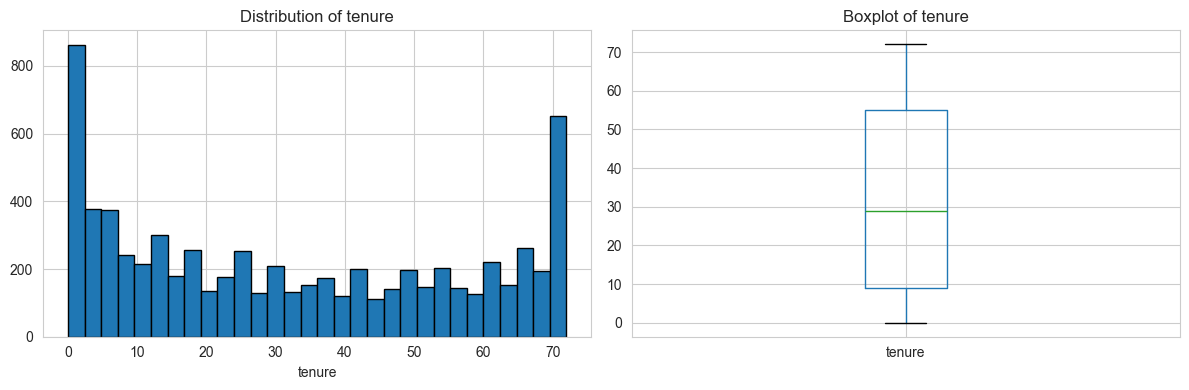

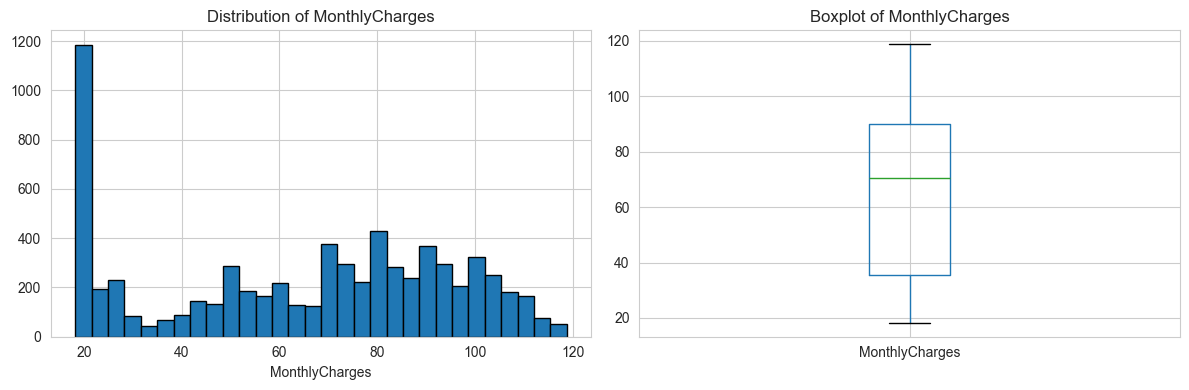

In [4]:
# Distribution of numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    
    plt.subplot(1, 2, 2)
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

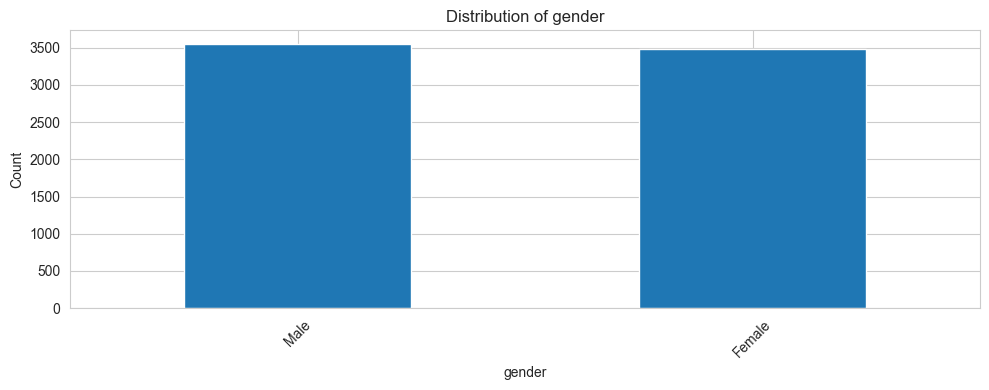

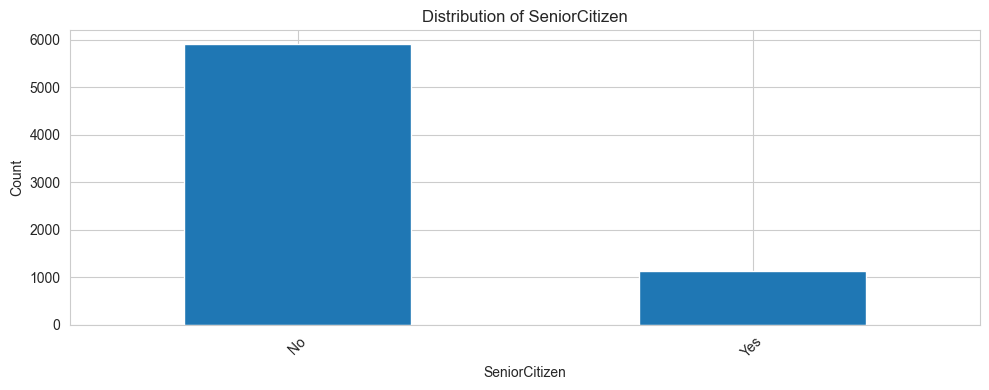

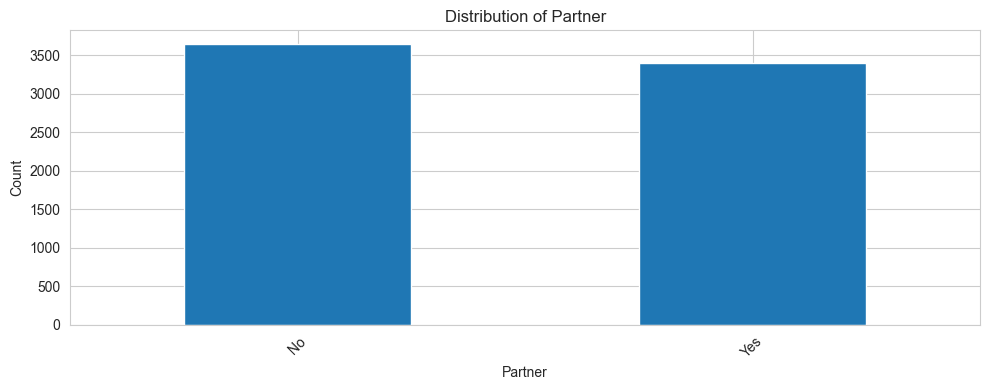

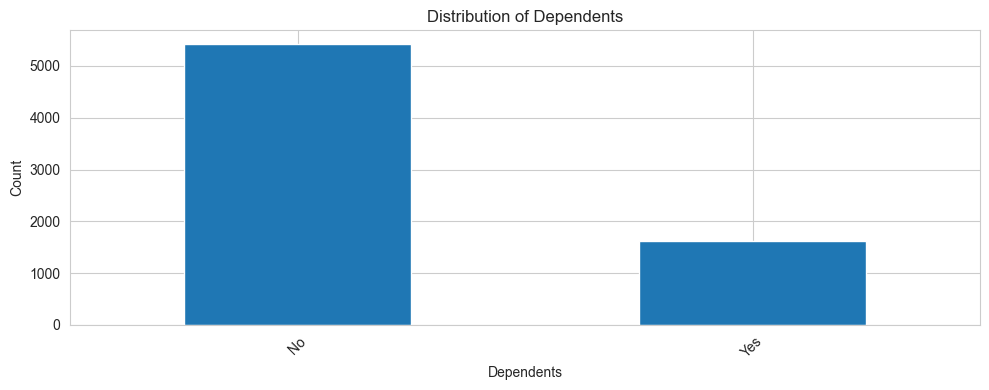

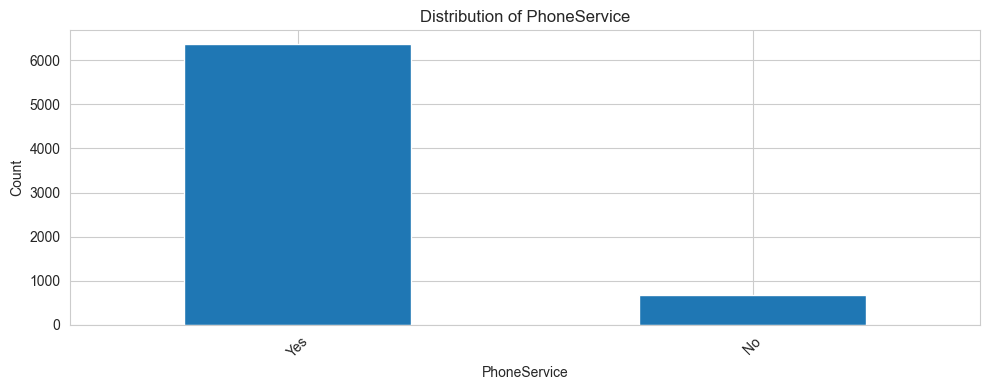

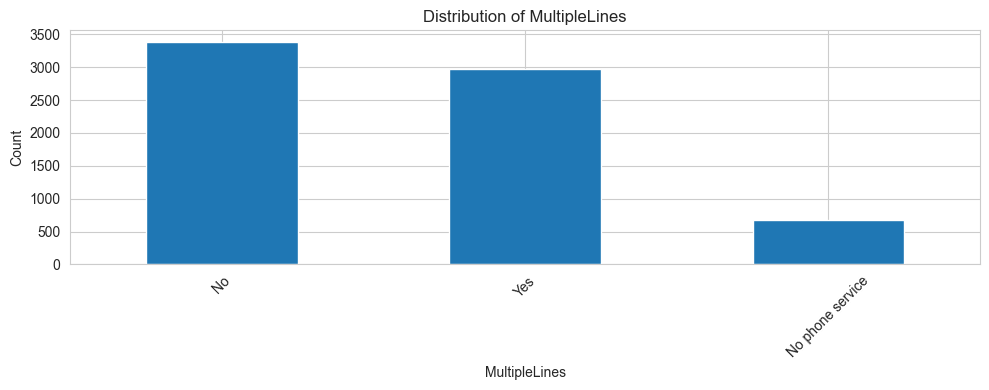

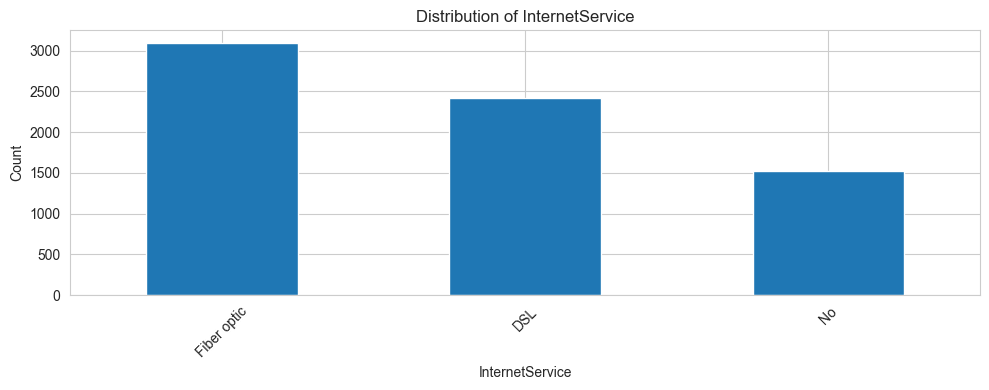

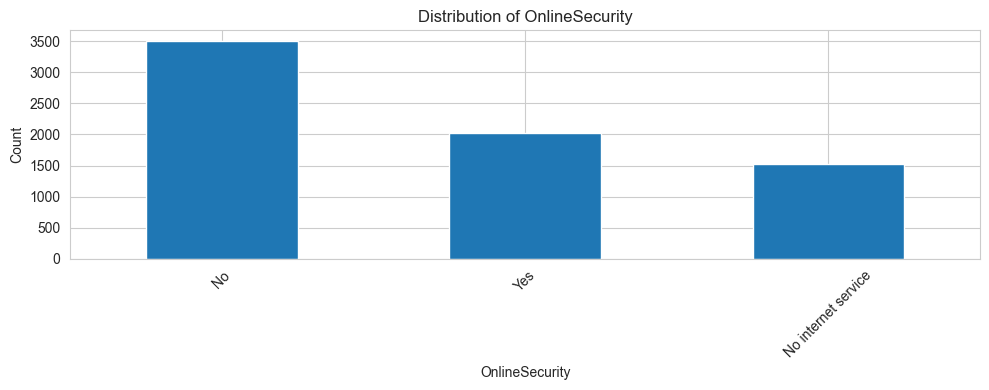

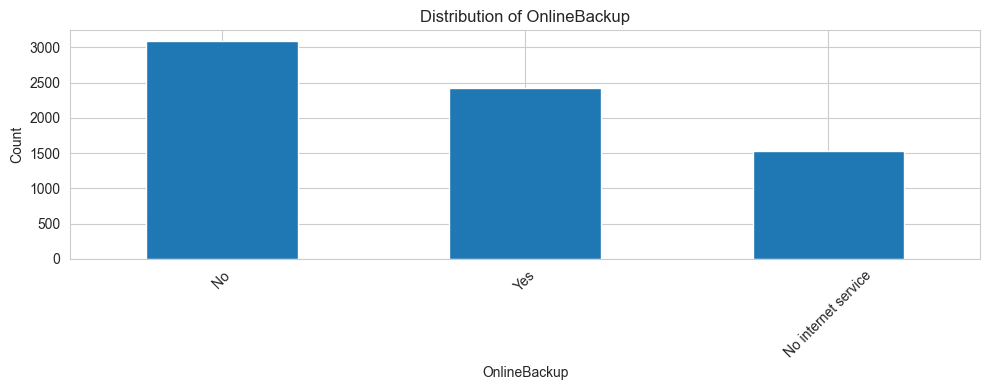

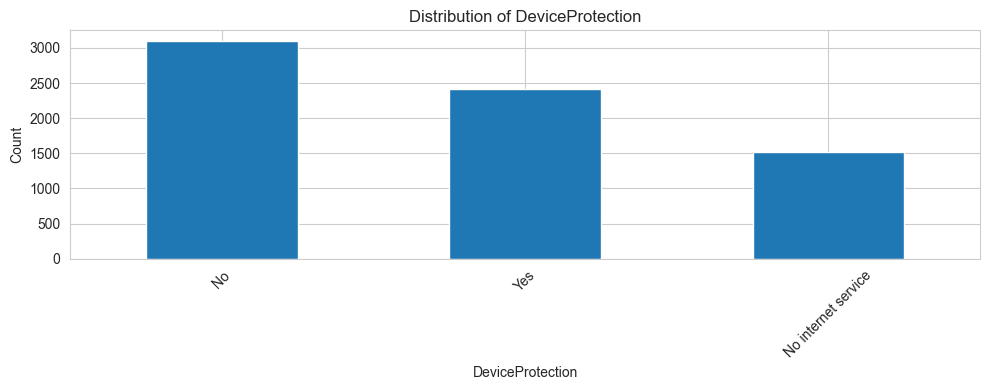

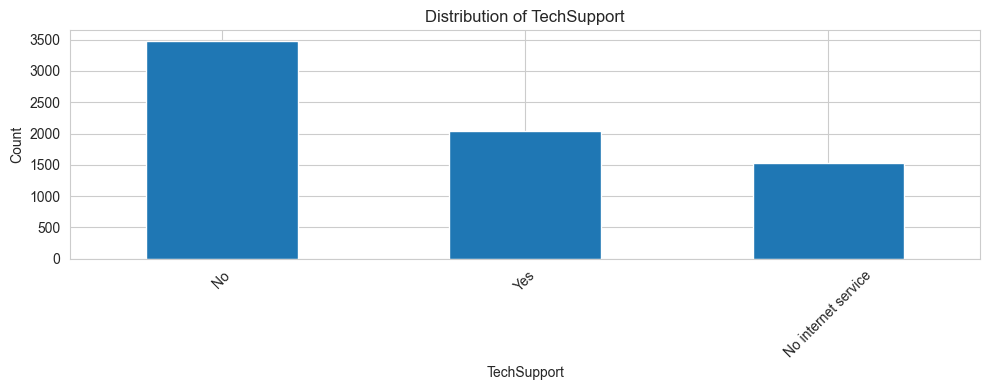

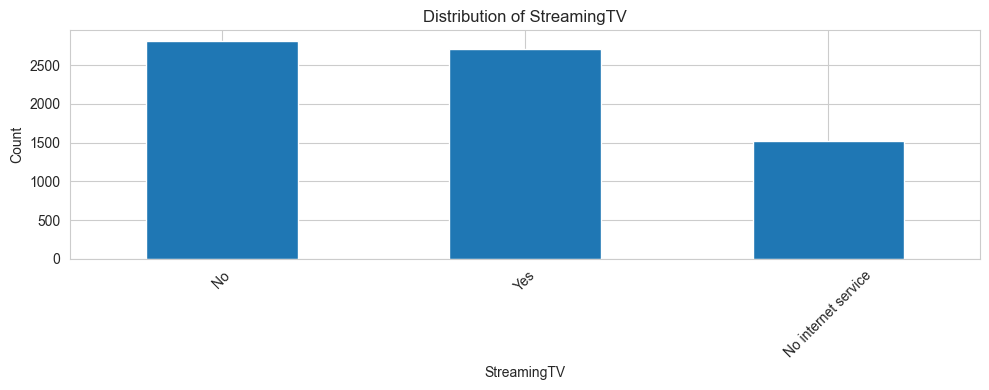

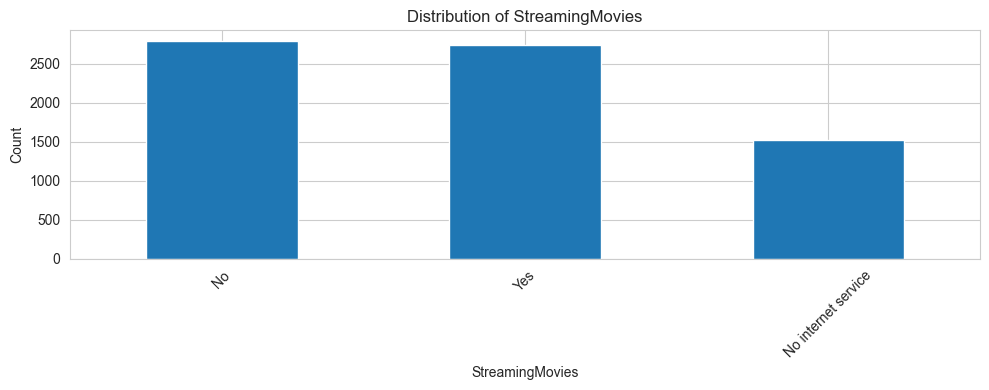

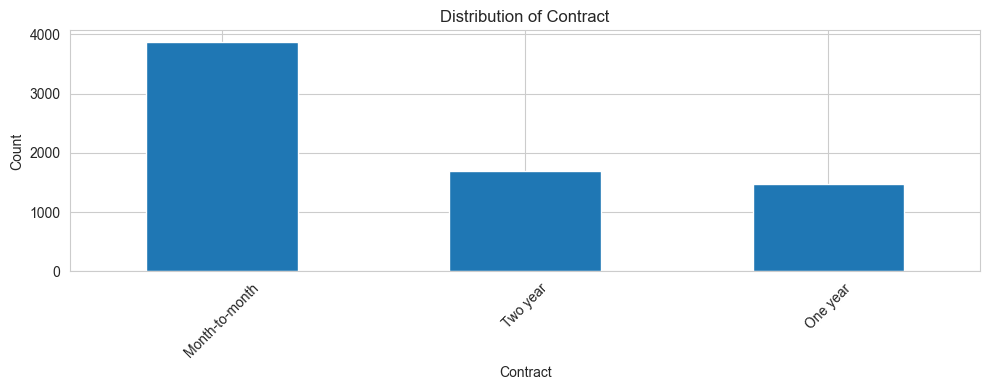

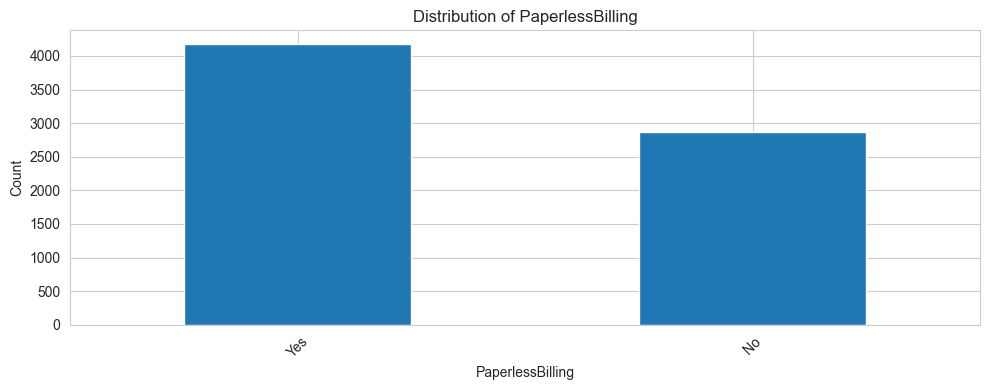

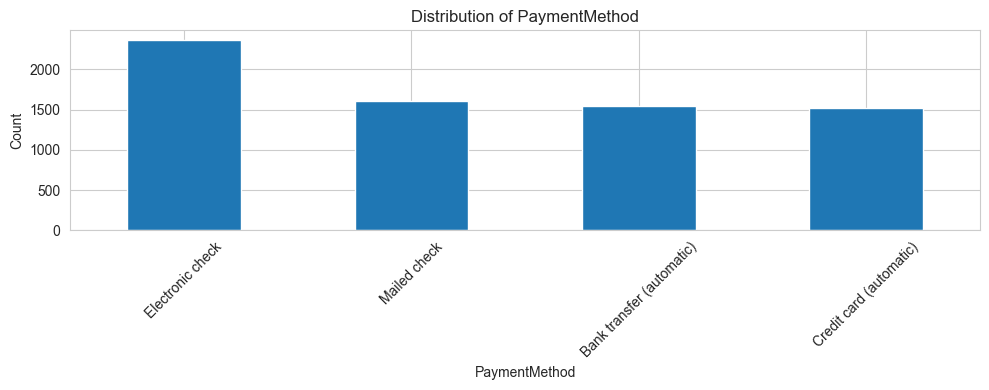

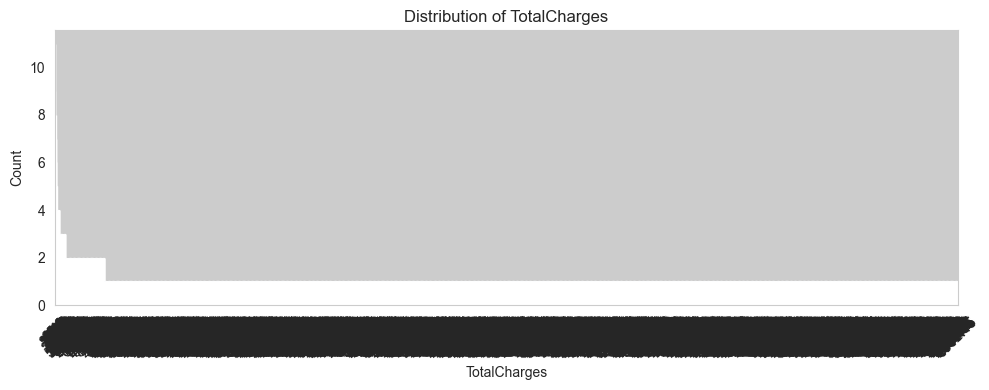

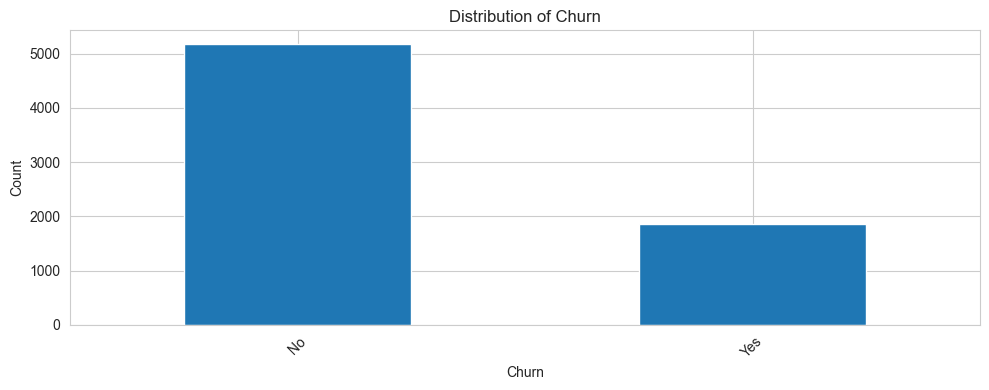

In [5]:
# Distribution of categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

<Figure size 1000x400 with 0 Axes>

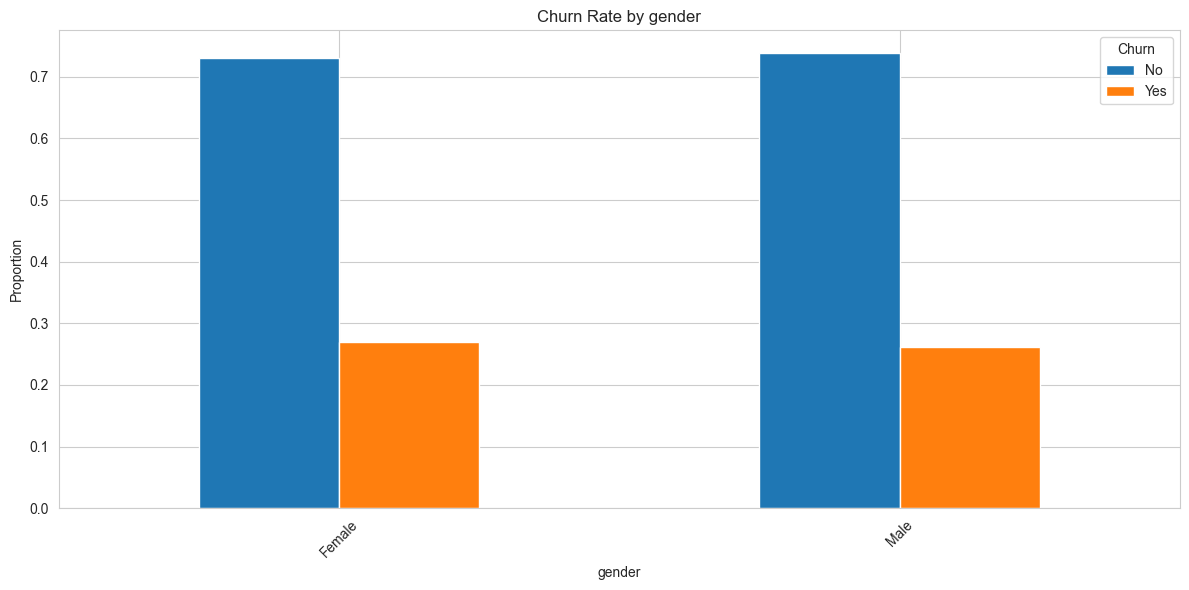

<Figure size 1000x400 with 0 Axes>

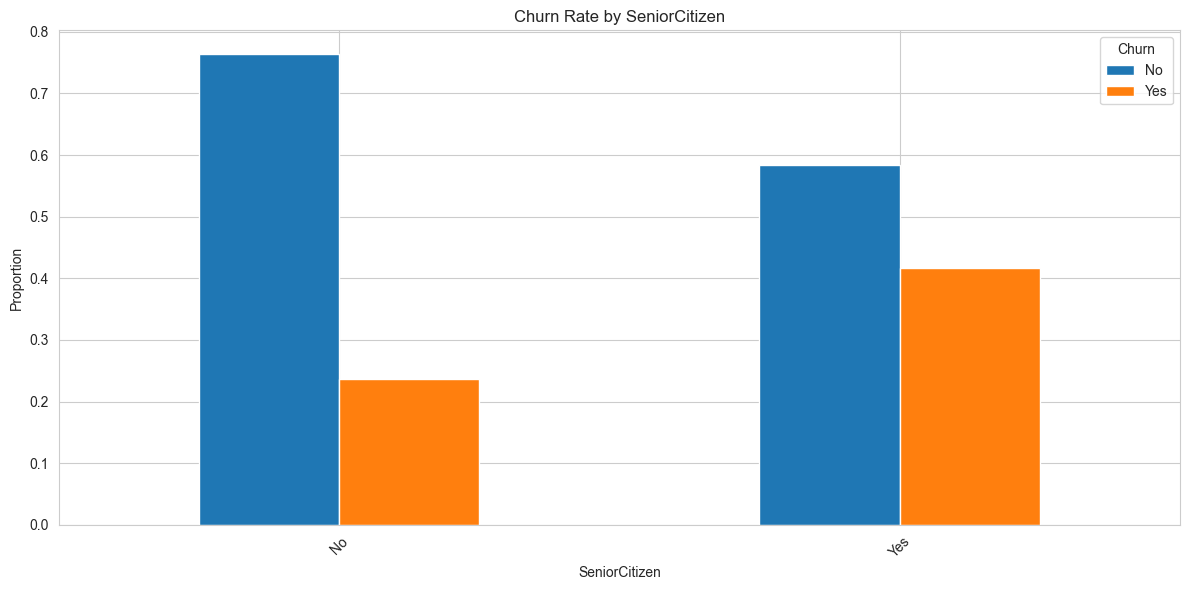

<Figure size 1000x400 with 0 Axes>

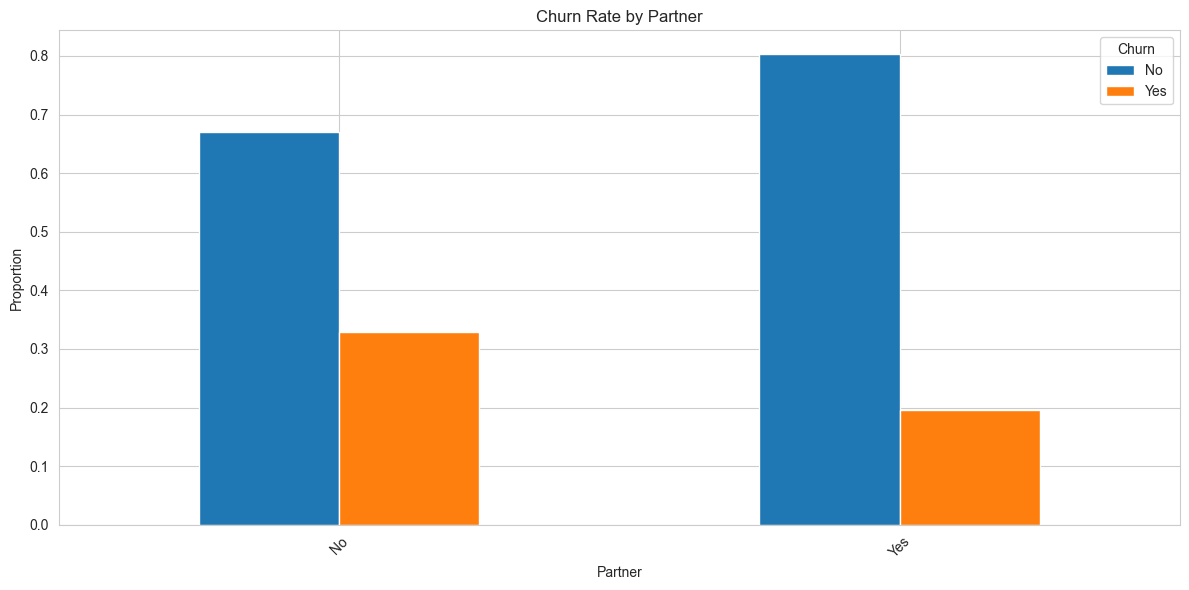

<Figure size 1000x400 with 0 Axes>

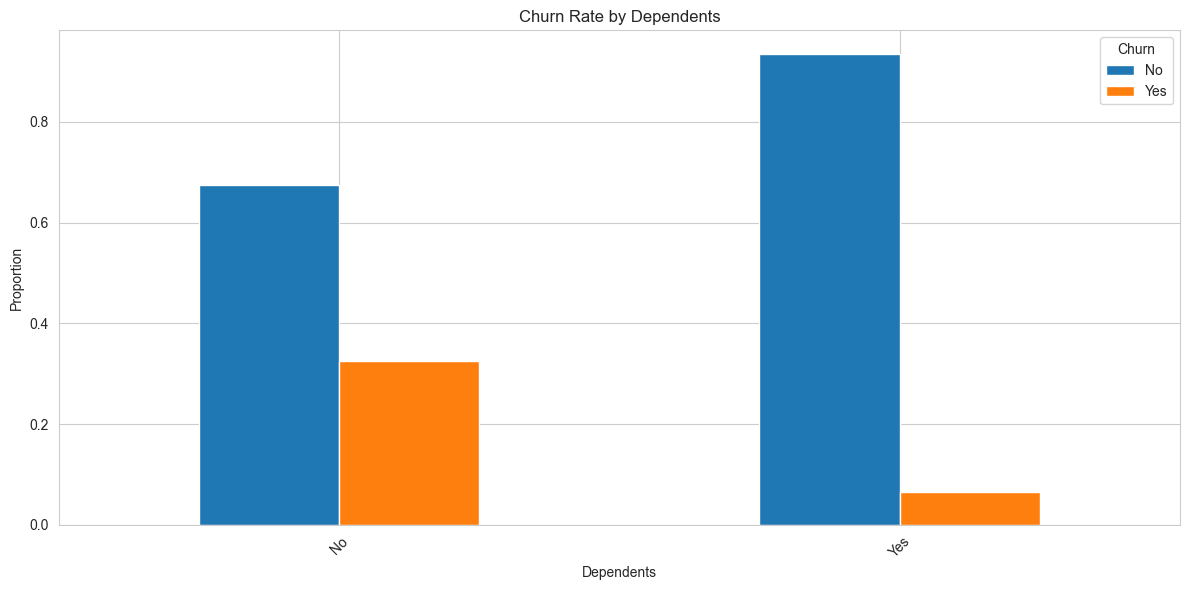

<Figure size 1000x400 with 0 Axes>

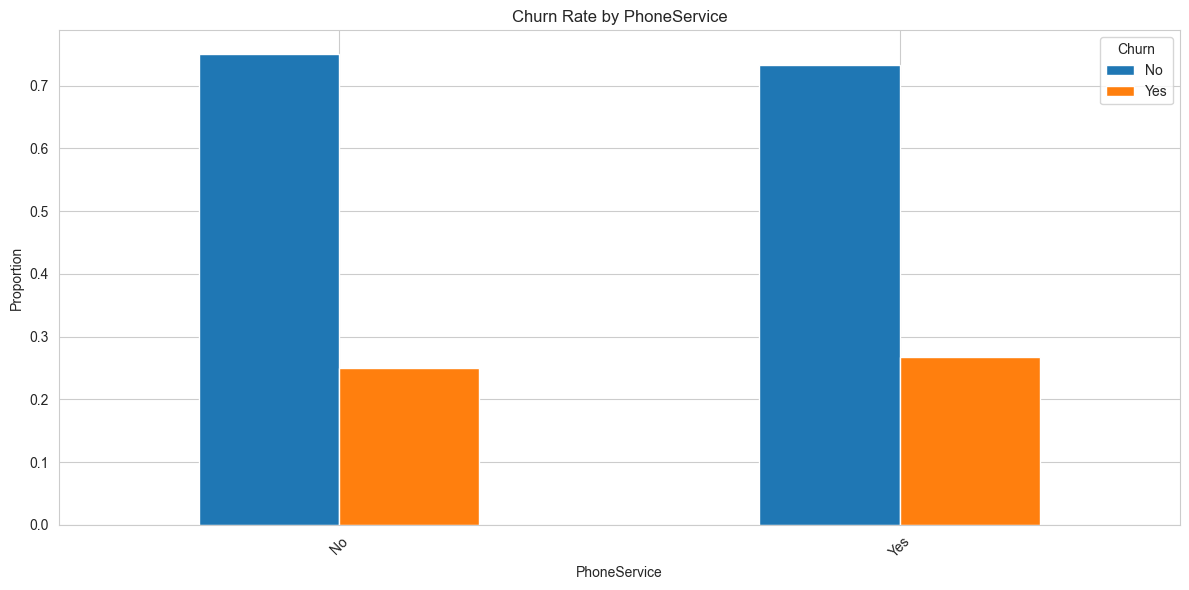

<Figure size 1000x400 with 0 Axes>

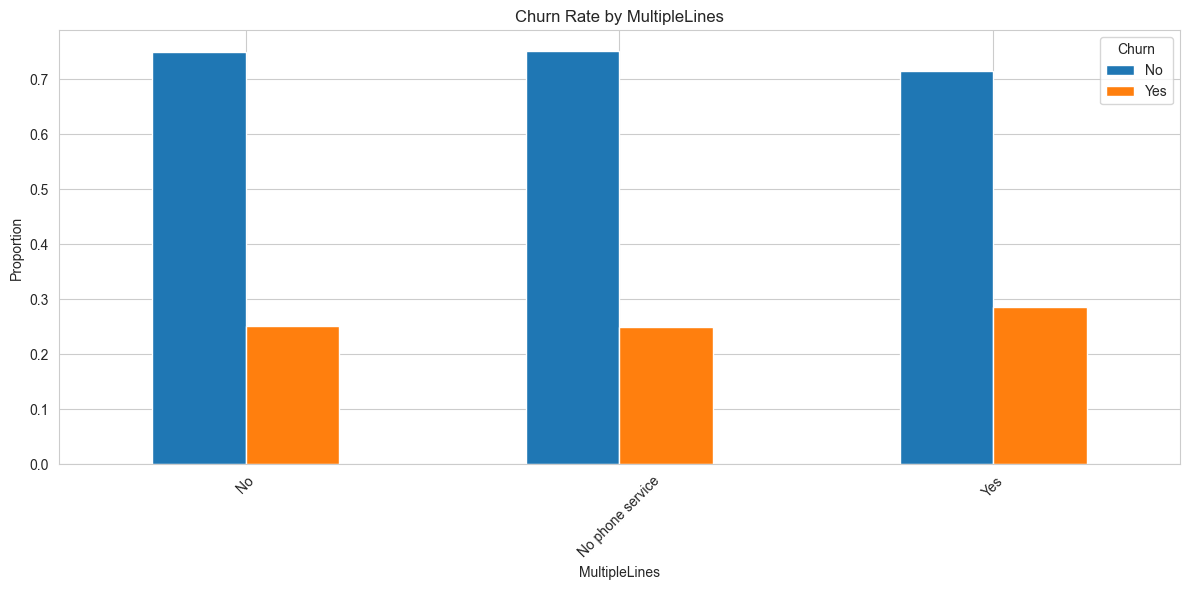

<Figure size 1000x400 with 0 Axes>

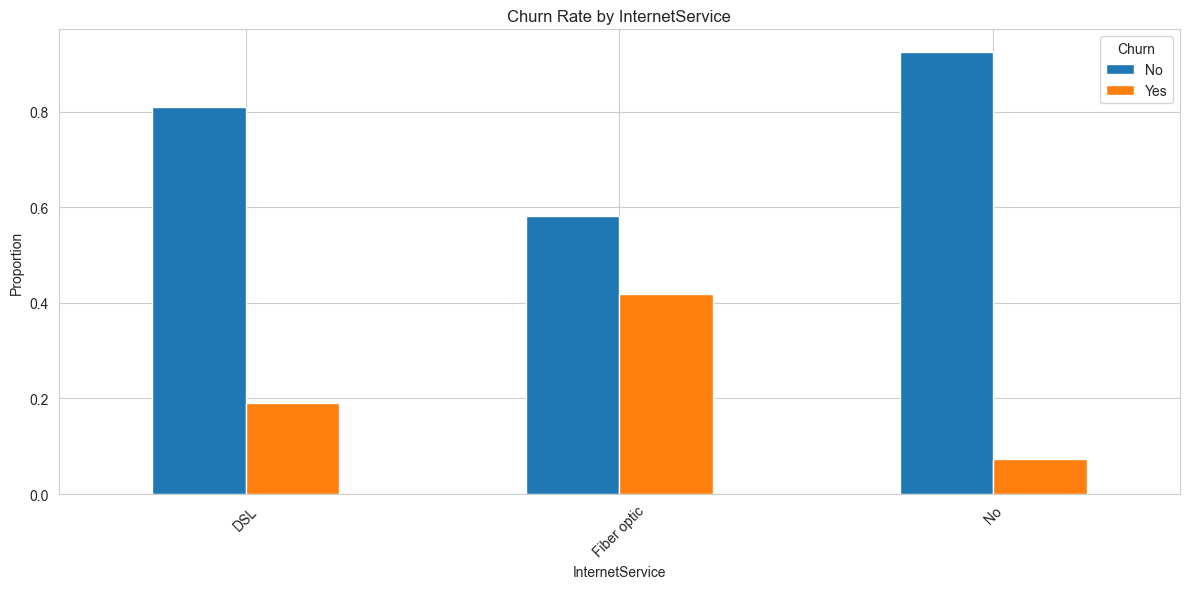

<Figure size 1000x400 with 0 Axes>

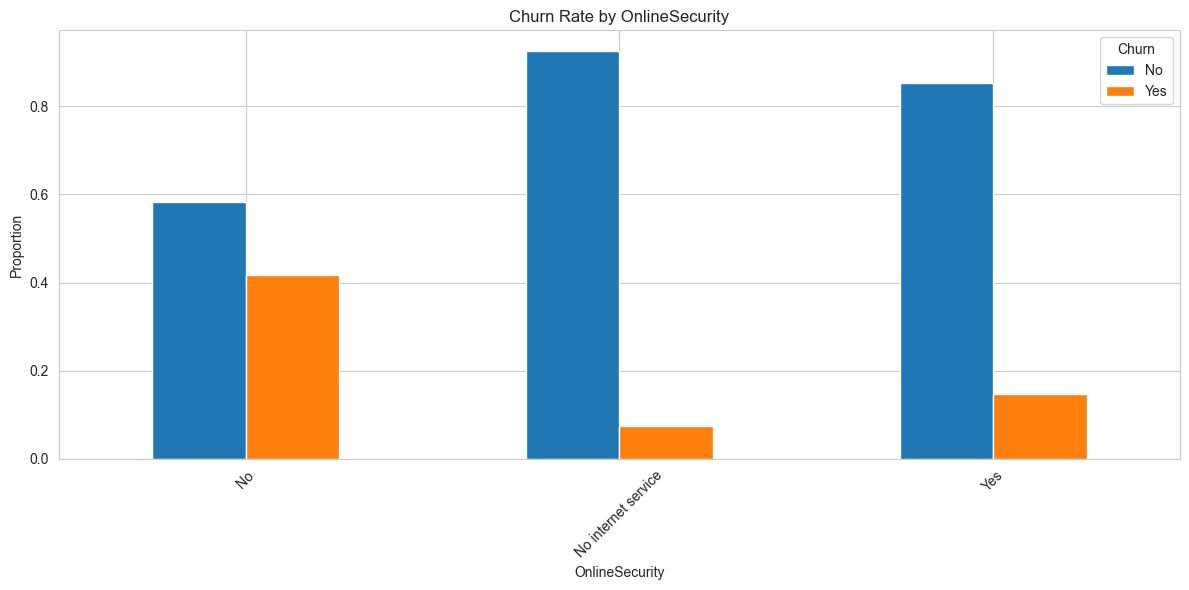

<Figure size 1000x400 with 0 Axes>

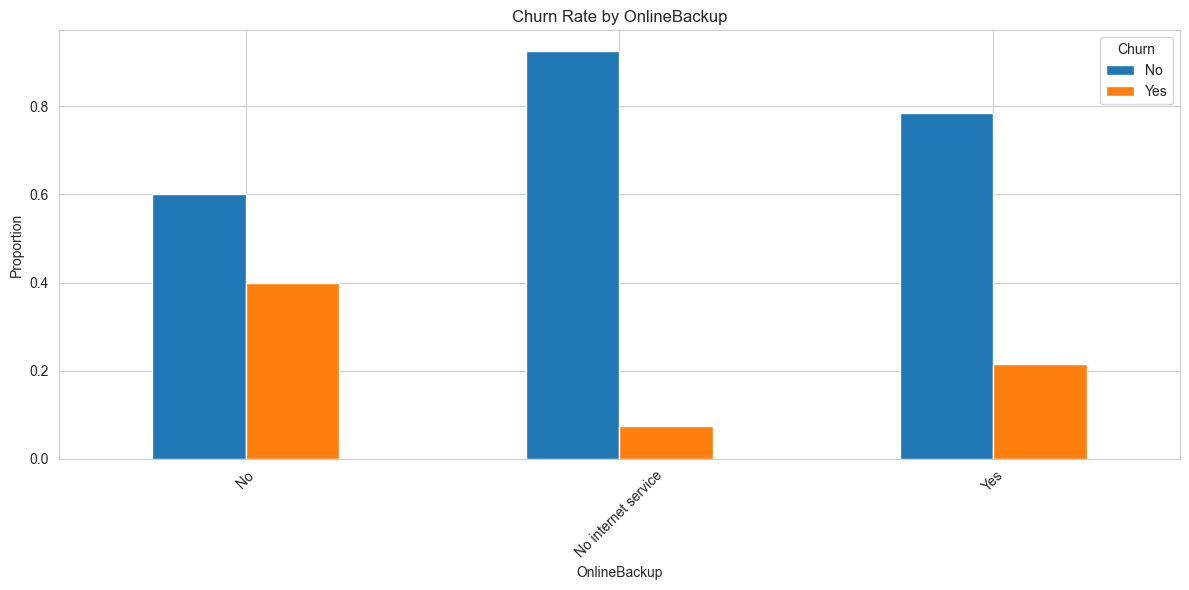

<Figure size 1000x400 with 0 Axes>

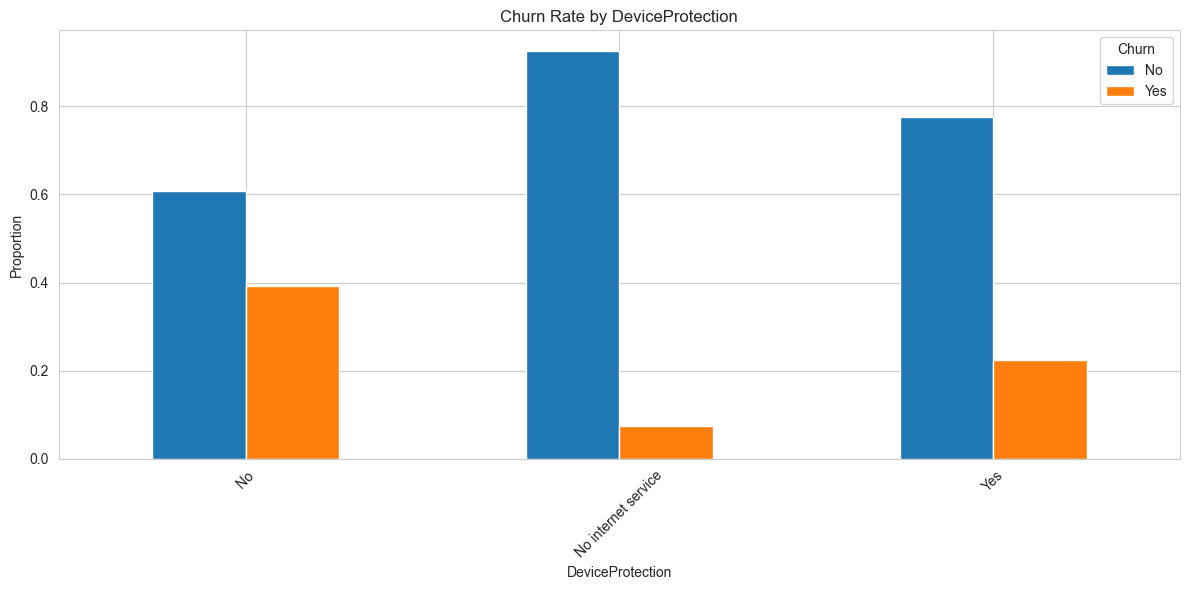

<Figure size 1000x400 with 0 Axes>

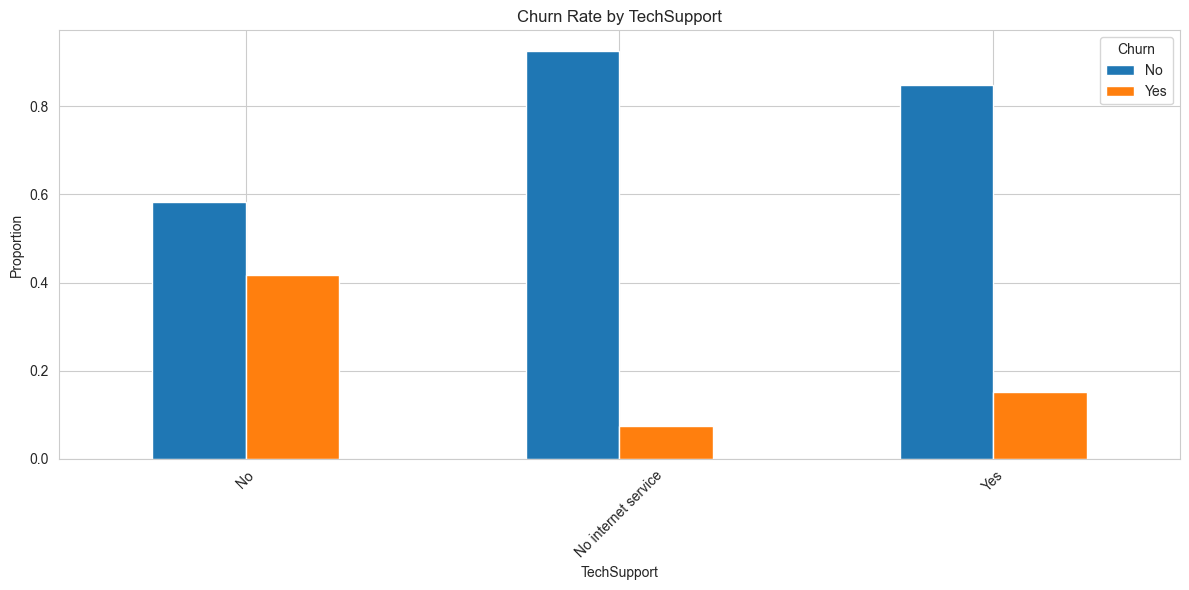

<Figure size 1000x400 with 0 Axes>

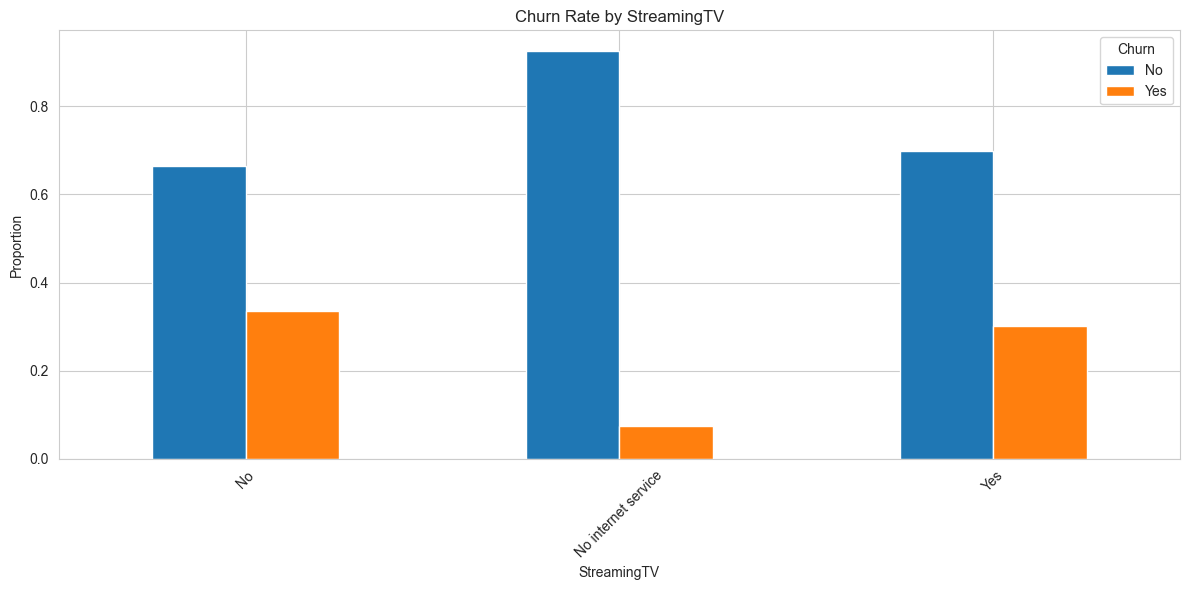

<Figure size 1000x400 with 0 Axes>

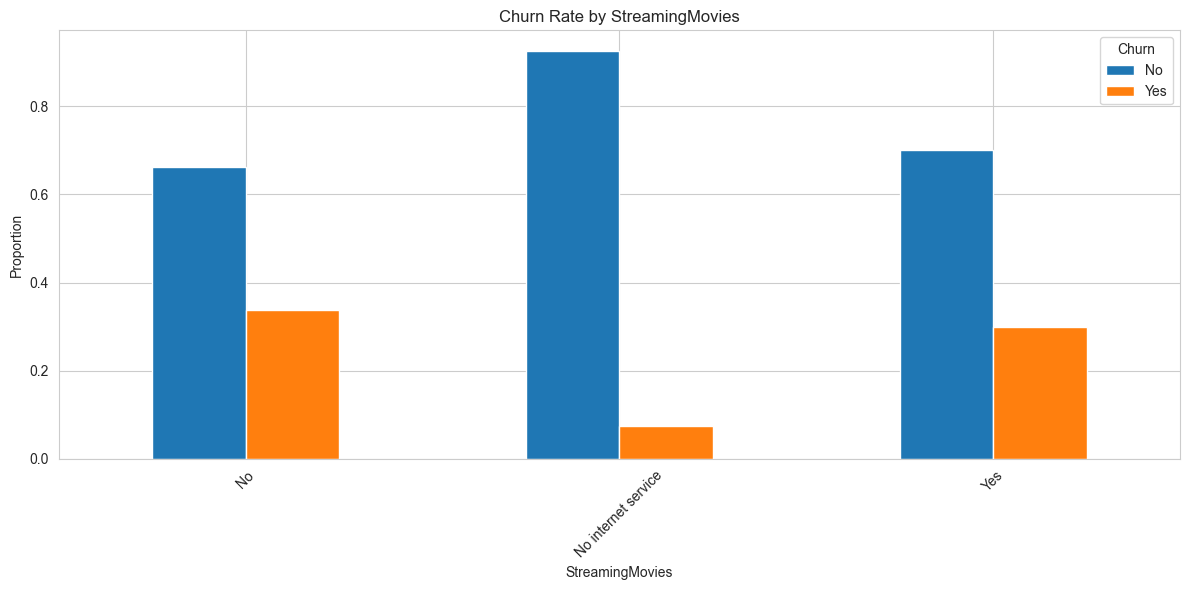

<Figure size 1000x400 with 0 Axes>

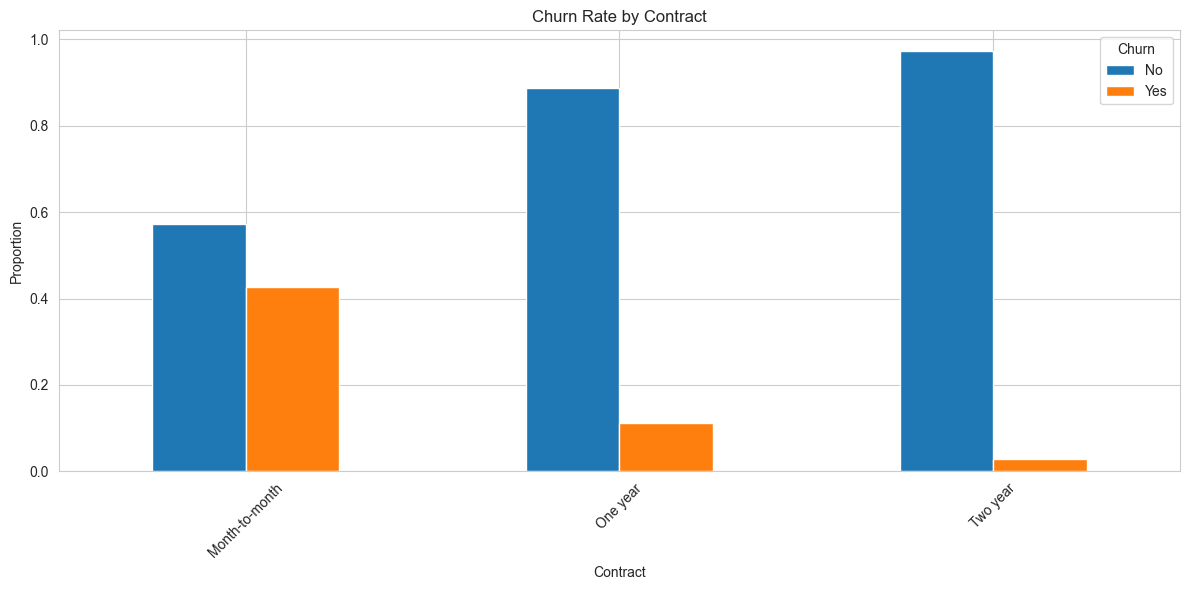

<Figure size 1000x400 with 0 Axes>

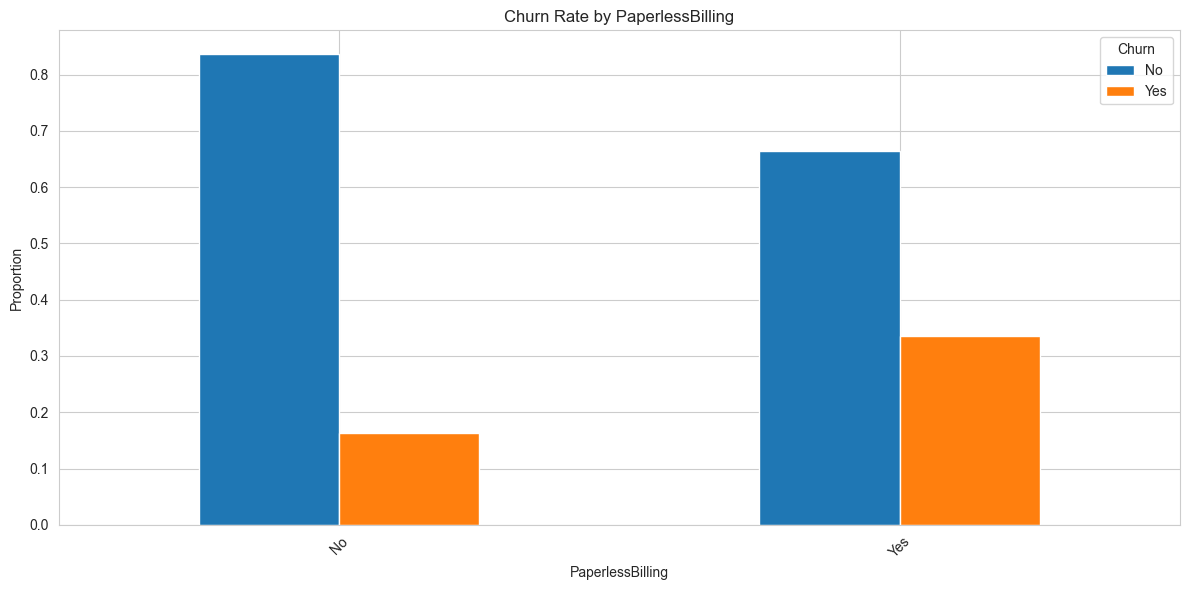

<Figure size 1000x400 with 0 Axes>

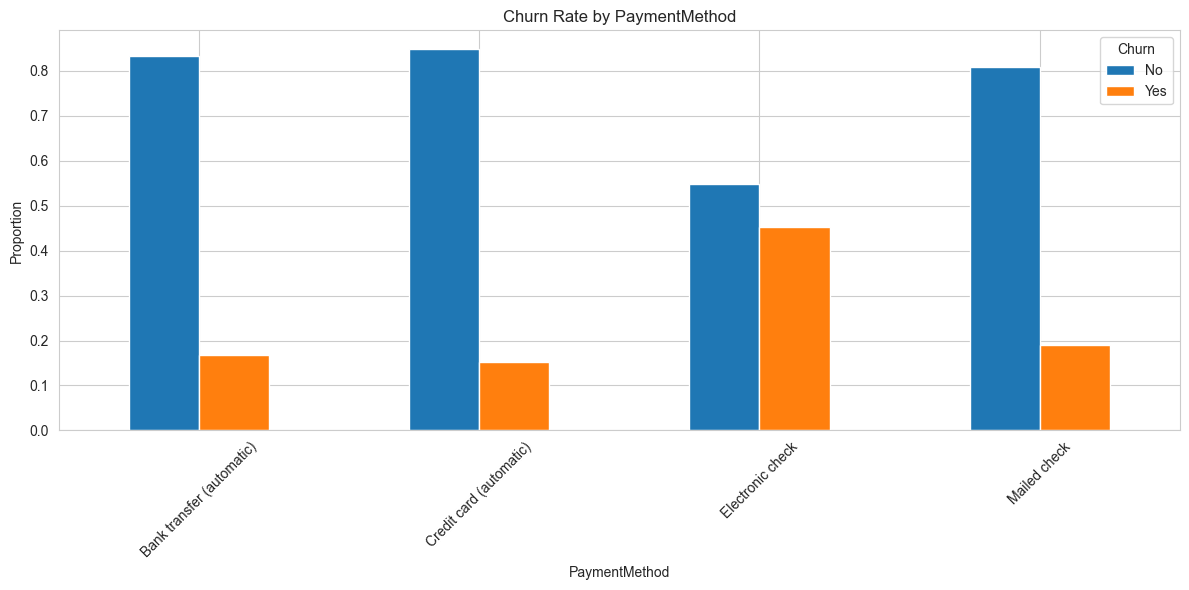

<Figure size 1000x400 with 0 Axes>

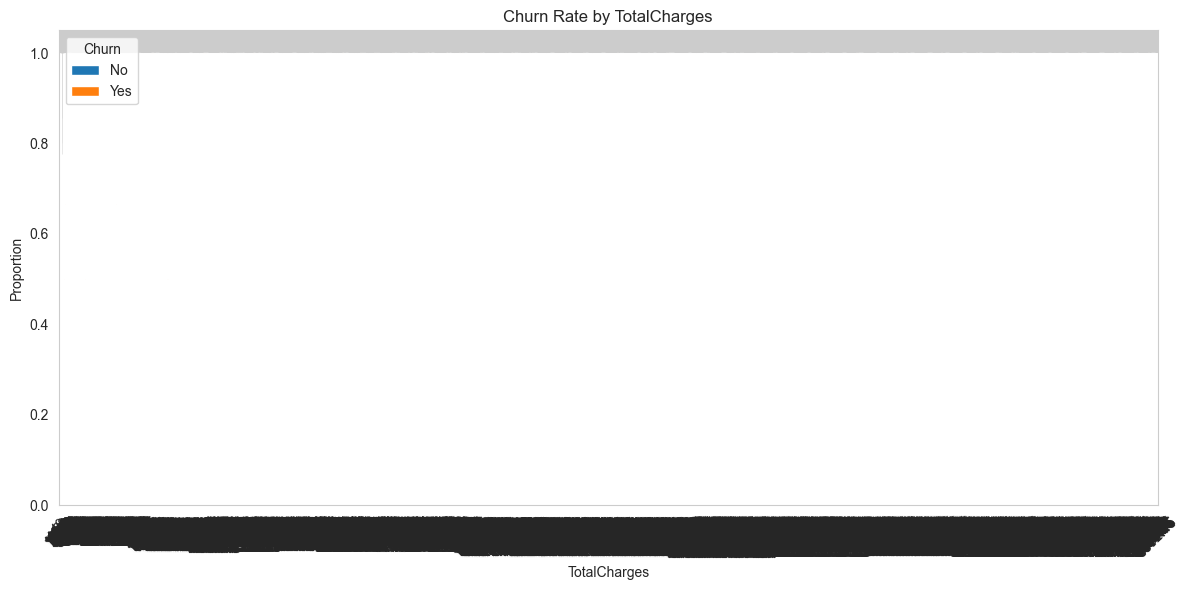

In [6]:
# Churn rate by categorical features
if 'Churn' in df.columns:
    for col in categorical_cols:
        if col != 'Churn':
            plt.figure(figsize=(10, 4))
            churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
            churn_rate.plot(kind='bar', stacked=False)
            plt.title(f'Churn Rate by {col}')
            plt.ylabel('Proportion')
            plt.xticks(rotation=45)
            plt.legend(title='Churn')
            plt.tight_layout()
            plt.show()

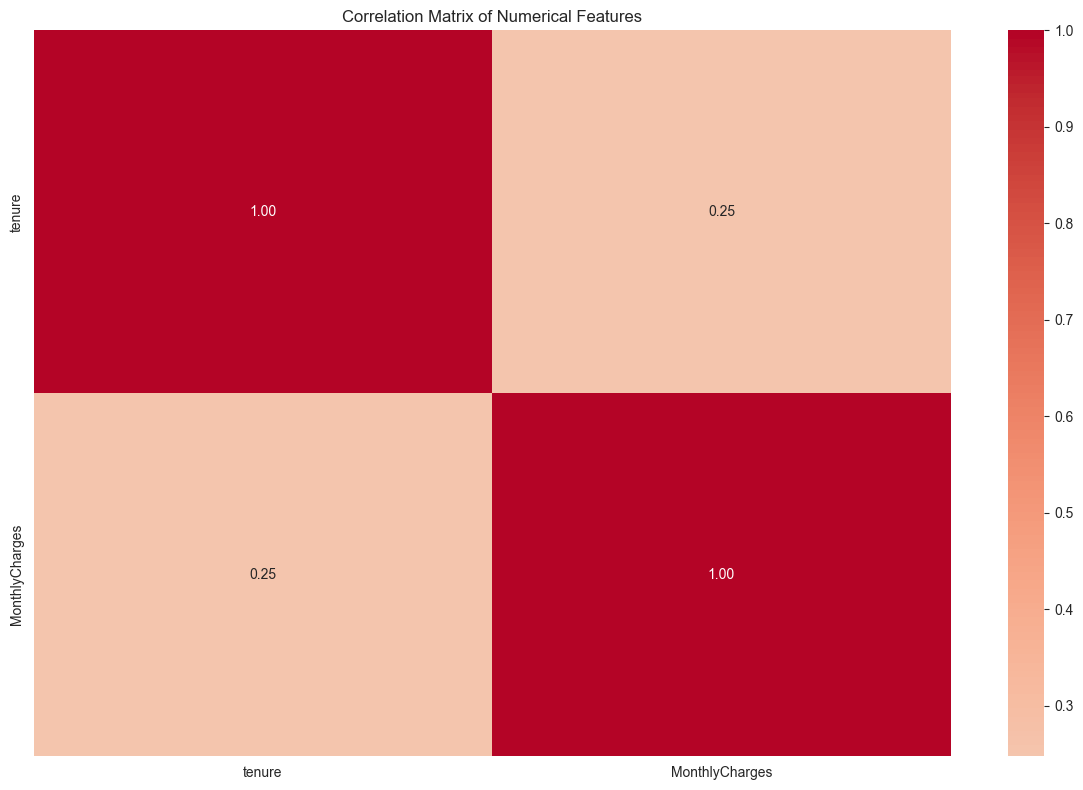

In [7]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

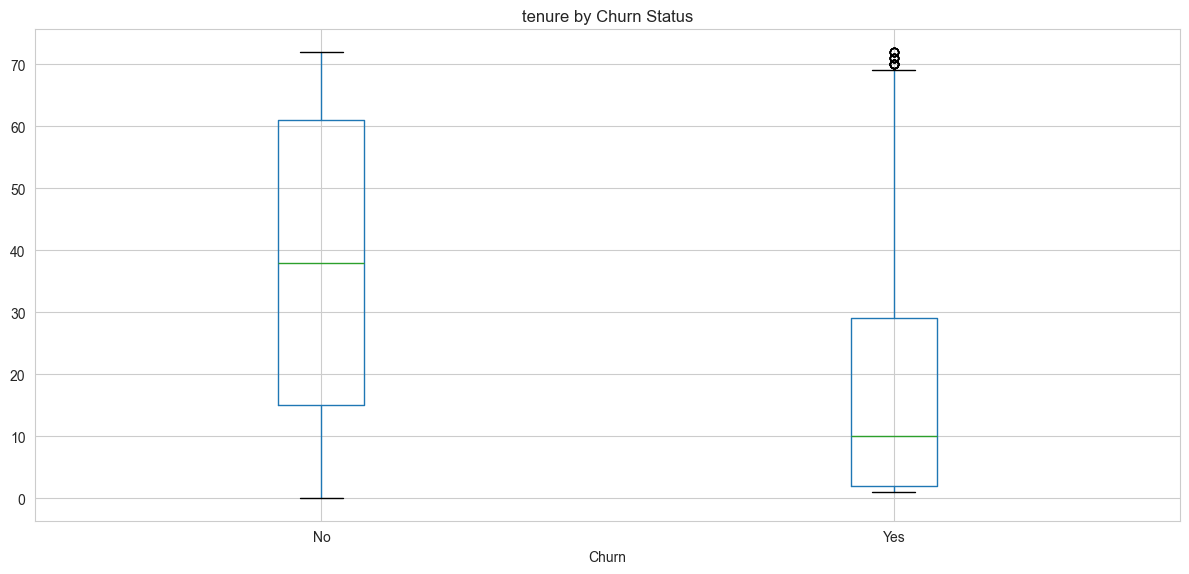

<Figure size 1000x400 with 0 Axes>

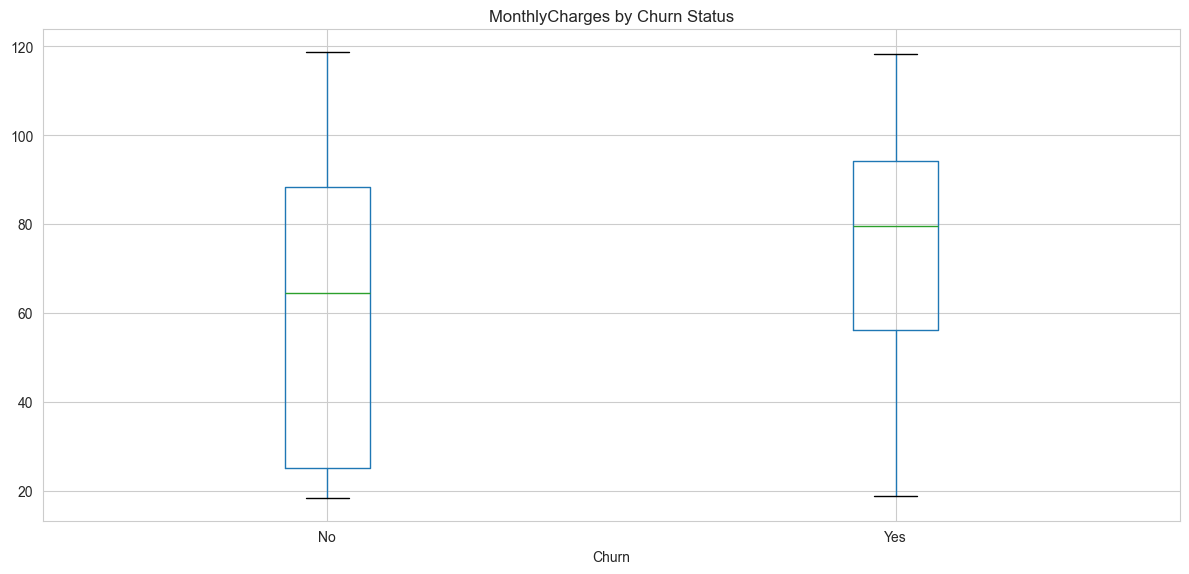

In [8]:
# Numerical features vs Churn
if 'Churn' in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(10, 4))
        df.boxplot(column=col, by='Churn')
        plt.title(f'{col} by Churn Status')
        plt.suptitle('')
        plt.tight_layout()
        plt.show()

## Key Insights

Document key findings from the EDA:
- Feature distributions
- Relationships with target variable
- Potential outliers
- Feature correlations